# ConformalLocalizer — L Sudden 3

Evaluates `ConformalLocalizer` on a **binary classification stream with 3 sudden concept drift events**.

| Phase | Samples | Description |
|-------|---------|-------------|
| 0     | 0 – 999   | Initial distribution — used for training |
| 1     | 1000 – 1999 | After **drift #1**: 90° rotation of class means |
| 2     | 2000 – 2999 | After **drift #2**: another 90° rotation |
| 3     | 3000 – 3999 | After **drift #3**: another 90° rotation |

The localizer is trained **once** on phase 0 and then applied to the whole stream.
Low p-values indicate samples that look anomalous w.r.t. the training distribution.

In [1]:
import sys
import os

# Make sure src is on the path when running from the playground/ folder
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay

from conformal.conformal_localizer import ConformalLocalizer

rng = np.random.default_rng(42)

## 1 — Synthetic "L Sudden 3" stream

Four segments, each with 1 000 balanced binary samples (500 per class).
Drift is implemented as a **90° rotation** of the class-mean positions around the origin, making
the post-drift data look out-of-distribution to a model trained on phase 0.

In [2]:
N_PER_PHASE = 1_000   # samples in each phase (balanced: 500 per class)
N_PHASES    = 4       # phase 0 = train, phases 1-3 = stream with 3 drift events
N_FEATURES  = 10      # total feature dimensions (first 2 are informative / visualised)
NOISE_STD   = 0.6     # within-class spread
DRIFT_ANGLE = np.pi / 2  # 90° rotation per drift event
ALPHA       = 0.2     # conformal significance level

# Drift positions (first sample index of each new phase)
DRIFT_POSITIONS = [N_PER_PHASE * p for p in range(1, N_PHASES)]


def rotation_matrix(angle):
    c, s = np.cos(angle), np.sin(angle)
    R = np.eye(N_FEATURES)
    R[0, 0], R[0, 1] = c, -s
    R[1, 0], R[1, 1] = s,  c
    return R


def make_phase(n_per_class, rotation):
    """Generate one phase: 2 Gaussian clusters rotated by `rotation` radians."""
    # Base means for class 0 and class 1
    base_mean = np.zeros(N_FEATURES)
    base_mean[0] = 1.5
    R = rotation_matrix(rotation)
    mean0 =  R @ base_mean
    mean1 = -R @ base_mean

    X0 = rng.normal(loc=mean0, scale=NOISE_STD, size=(n_per_class, N_FEATURES))
    X1 = rng.normal(loc=mean1, scale=NOISE_STD, size=(n_per_class, N_FEATURES))
    X  = np.vstack([X0, X1])
    y  = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)]).astype(int)

    # Shuffle within phase
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


phases_X, phases_y = [], []
for p in range(N_PHASES):
    Xp, yp = make_phase(N_PER_PHASE // 2, rotation=p * DRIFT_ANGLE)
    phases_X.append(Xp)
    phases_y.append(yp)

X_train, y_train = phases_X[0], phases_y[0]   # phase 0 → training
X_stream = np.vstack(phases_X)                 # full stream (all 4 phases)
y_stream = np.hstack(phases_y)
n_stream  = len(y_stream)

# Ground-truth drift mask: 1 inside the 50-sample window after each drift point
DRIFT_WINDOW = 50
drift_gt = np.zeros(n_stream, dtype=int)
for dp in DRIFT_POSITIONS:
    drift_gt[dp : dp + DRIFT_WINDOW] = 1

print(f"Training samples : {X_train.shape[0]}")
print(f"Stream samples   : {X_stream.shape[0]} (phases 0–3 concatenated)")
print(f"Drift positions  : {DRIFT_POSITIONS}")

Training samples : 1000
Stream samples   : 4000 (phases 0–3 concatenated)
Drift positions  : [1000, 2000, 3000]


## 2 — Visualise the stream dataset (first 2 features)

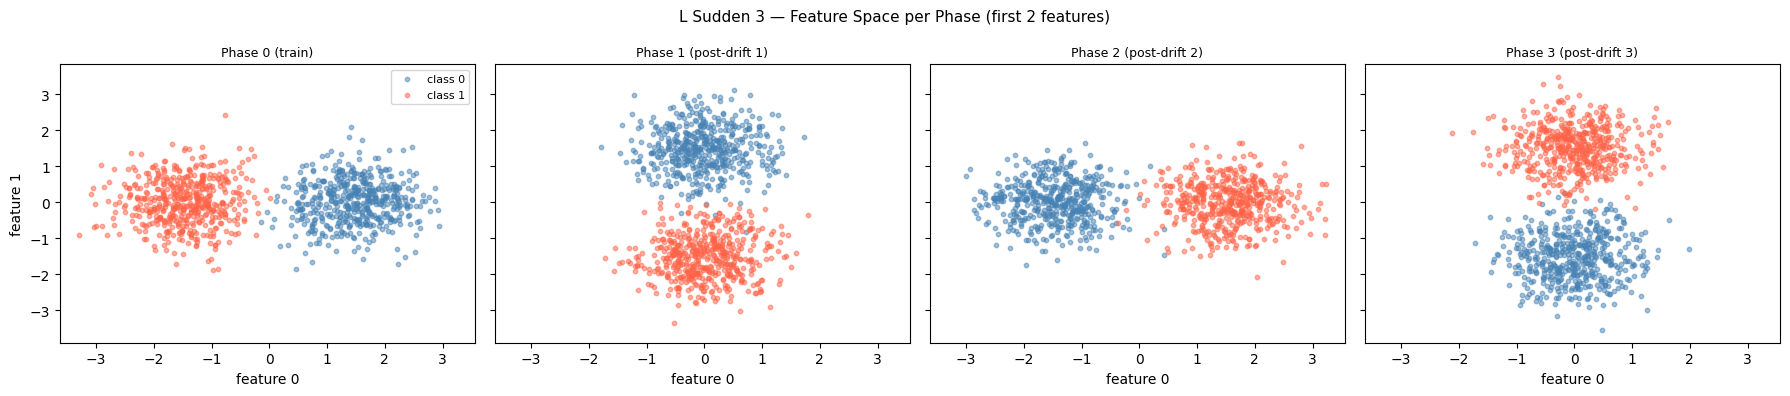

In [3]:
phase_colors = ['#4477AA', '#EE6677', '#228833', '#CCBB44']
phase_names  = ['Phase 0 (train)', 'Phase 1 (post-drift 1)',
                'Phase 2 (post-drift 2)', 'Phase 3 (post-drift 3)']

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
for p, ax in enumerate(axes):
    Xp, yp = phases_X[p], phases_y[p]
    ax.scatter(Xp[yp == 0, 0], Xp[yp == 0, 1], s=10, alpha=0.5, label='class 0', color='steelblue')
    ax.scatter(Xp[yp == 1, 0], Xp[yp == 1, 1], s=10, alpha=0.5, label='class 1', color='tomato')
    ax.set_title(phase_names[p], fontsize=9)
    ax.set_xlabel('feature 0')
    if p == 0:
        ax.set_ylabel('feature 1')
        ax.legend(fontsize=8)

fig.suptitle('L Sudden 3 — Feature Space per Phase (first 2 features)', fontsize=11)
plt.tight_layout()
plt.show()

## 3 — Fit `ConformalLocalizer` on phase 0

In [4]:
base_model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
)

localizer = ConformalLocalizer(
    model=base_model,
    alpha=ALPHA,
    n_min_members=50,      # ensemble size — reduced for notebook speed
    bootstrap_fraction=0.8,
    cover_search=20,
    cv_params={},          # no grid-search in playground
    n_jobs=-1,
)

print('Fitting ConformalLocalizer on phase-0 training data …')
localizer.fit(X_train, y_train)
print('Done.')
print()
for k, v in localizer.get_info().items():
    print(f'  {k:20s}: {v}')

Fitting ConformalLocalizer on phase-0 training data …
Done.

  base model          : RandomForestClassifier(max_depth=5, n_jobs=-1, random_state=42)
  cv parameter        : {}
  cv runs             : 5
  localizer model     : KNeighborsRegressor(n_neighbors=1)
  min members         : 50
  bootstrap fraction  : 0.8
  cover_search        : 20
  alpha               : 0.2
  jobs                : -1
  call                : ConformalLocalizer(bootstrap_fraction=0.8, cover_search=20,
                   model=RandomForestClassifier(max_depth=5, n_jobs=-1,
                                                random_state=42),
                   n_min_members=50)
  class               : ConformalLocalizer


## 4 — Score the full stream

In [5]:
p_values  = localizer.score_samples(X_stream)   # shape (n_stream,)
anomalies = localizer.predict(X_stream)          # True where p-value < alpha

# Smooth p-values with a rolling window for cleaner visualisation
WINDOW = 30
p_smooth = np.convolve(p_values, np.ones(WINDOW) / WINDOW, mode='same')

print(f'Overall anomaly rate : {anomalies.mean():.3f}')
phase_labels = np.repeat(np.arange(N_PHASES), N_PER_PHASE)
for p in range(N_PHASES):
    mask = phase_labels == p
    print(f'  Phase {p} anomaly rate: {anomalies[mask].mean():.3f}  '
          f'(median p={np.median(p_values[mask]):.3f})')

Overall anomaly rate : 1.000
  Phase 0 anomaly rate: 1.000  (median p=0.005)
  Phase 1 anomaly rate: 1.000  (median p=0.005)
  Phase 2 anomaly rate: 1.000  (median p=0.005)
  Phase 3 anomaly rate: 1.000  (median p=0.005)


## 5 — P-value trace over the stream

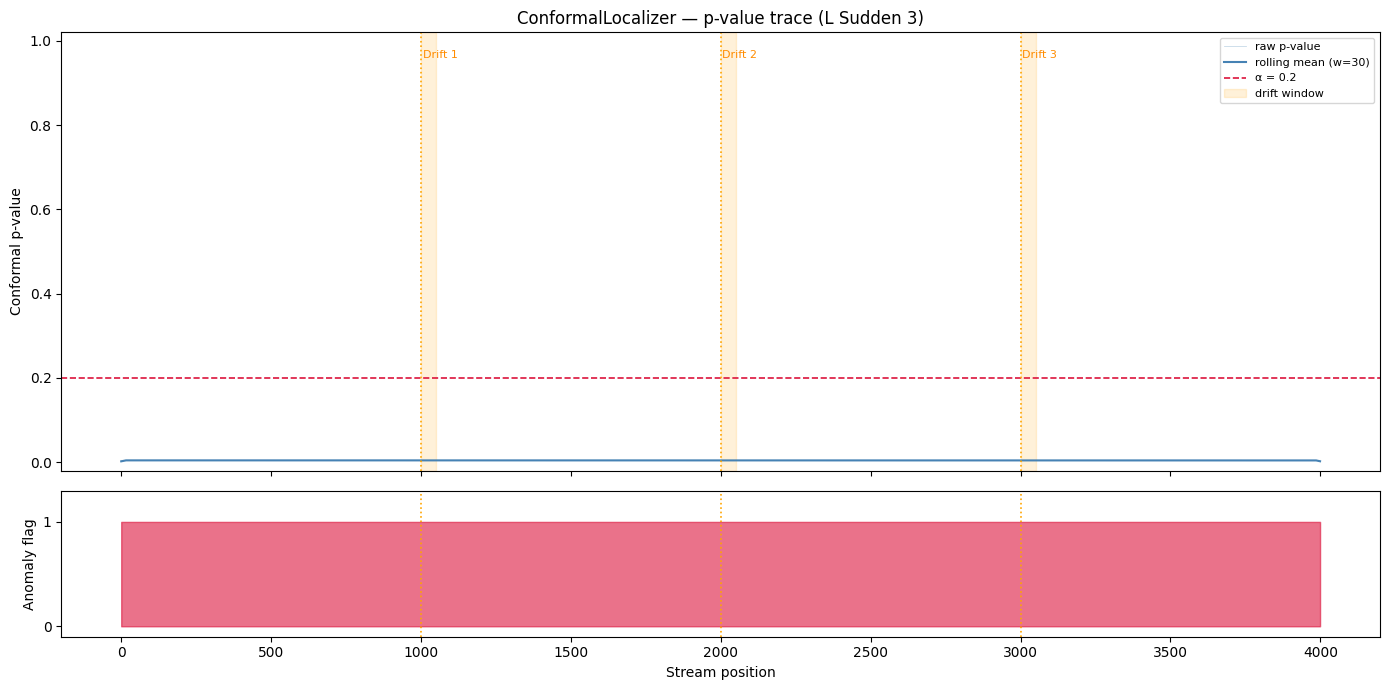

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

ax_p, ax_a = axes

# --- p-value trace ---
ax_p.plot(p_values,  color='steelblue', alpha=0.3, linewidth=0.6, label='raw p-value')
ax_p.plot(p_smooth,  color='steelblue', linewidth=1.5, label=f'rolling mean (w={WINDOW})')
ax_p.axhline(ALPHA, color='crimson', linestyle='--', linewidth=1.2, label=f'α = {ALPHA}')

for i, dp in enumerate(DRIFT_POSITIONS):
    ax_p.axvspan(dp, dp + DRIFT_WINDOW, alpha=0.15, color='orange',
                 label='drift window' if i == 0 else None)
    ax_p.axvline(dp, color='orange', linewidth=1.2, linestyle=':')
    ax_p.text(dp + 5, 0.96, f'Drift {i+1}', fontsize=8, color='darkorange')

ax_p.set_ylabel('Conformal p-value')
ax_p.set_title('ConformalLocalizer — p-value trace (L Sudden 3)')
ax_p.set_ylim(-0.02, 1.02)
ax_p.legend(loc='upper right', fontsize=8)

# --- anomaly flag bar ---
ax_a.fill_between(range(n_stream), anomalies.astype(int),
                  color='crimson', alpha=0.6, step='mid')
for dp in DRIFT_POSITIONS:
    ax_a.axvline(dp, color='orange', linewidth=1.2, linestyle=':')
ax_a.set_ylabel('Anomaly flag')
ax_a.set_xlabel('Stream position')
ax_a.set_yticks([0, 1])
ax_a.set_ylim(-0.1, 1.3)

plt.tight_layout()
plt.show()

## 6 — Feature-space coloured by p-value (phase 0 vs phase 1)

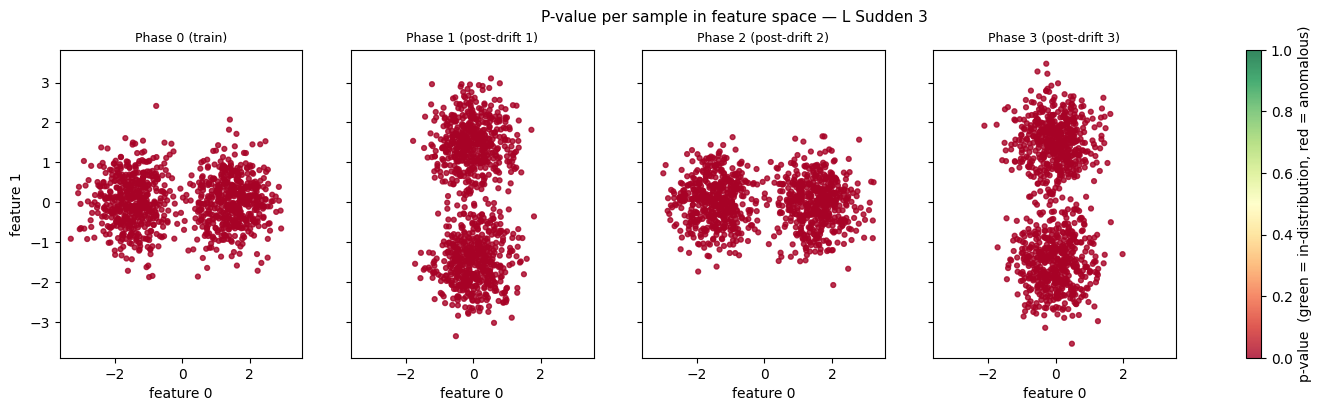

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)

for p, ax in enumerate(axes):
    start = p * N_PER_PHASE
    end   = start + N_PER_PHASE
    Xp    = X_stream[start:end]
    pv    = p_values[start:end]

    sc = ax.scatter(Xp[:, 0], Xp[:, 1], c=pv, cmap='RdYlGn',
                    vmin=0, vmax=1, s=12, alpha=0.8)
    ax.set_title(phase_names[p], fontsize=9)
    ax.set_xlabel('feature 0')
    if p == 0:
        ax.set_ylabel('feature 1')

fig.colorbar(sc, ax=axes.ravel().tolist(), label='p-value  (green = in-distribution, red = anomalous)')
fig.suptitle('P-value per sample in feature space — L Sudden 3', fontsize=11)
plt.show()

## 7 — Detection performance (ROC & Precision-Recall)

Ground truth: samples inside a **50-sample window starting at each drift point** are labelled as drifting.
The p-value (inverted so that low p ↔ high score) is used as the detection score.

ROC-AUC  (drift detection): 0.5171
PR-AUC   (drift detection): 0.0397


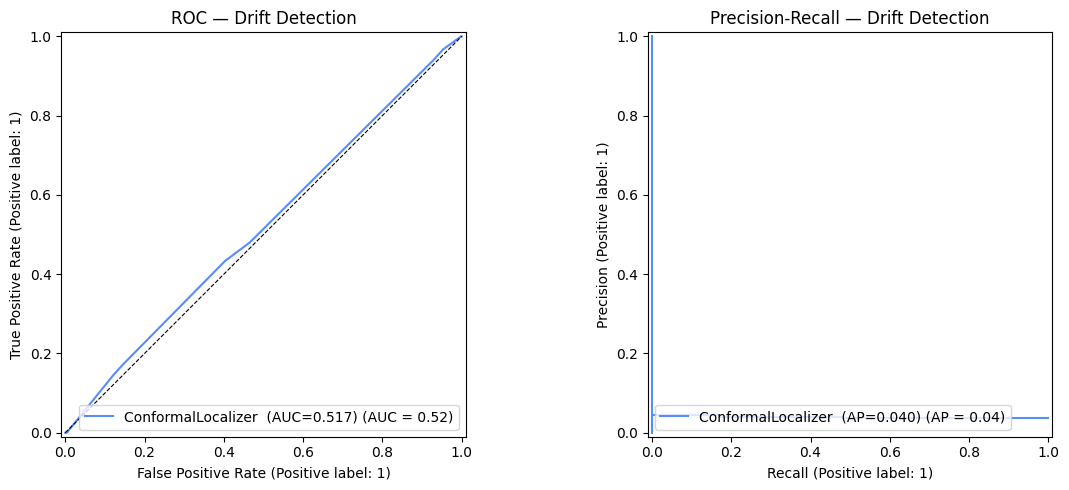

In [8]:
detection_score = 1.0 - p_values   # low p-value = high anomaly score

roc_auc = roc_auc_score(drift_gt, detection_score)
pr_auc  = average_precision_score(drift_gt, detection_score)

print(f'ROC-AUC  (drift detection): {roc_auc:.4f}')
print(f'PR-AUC   (drift detection): {pr_auc:.4f}')

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    drift_gt, detection_score,
    name=f'ConformalLocalizer  (AUC={roc_auc:.3f})',
    ax=ax_roc
)
ax_roc.set_title('ROC — Drift Detection')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=0.8)

PrecisionRecallDisplay.from_predictions(
    drift_gt, detection_score,
    name=f'ConformalLocalizer  (AP={pr_auc:.3f})',
    ax=ax_pr
)
ax_pr.set_title('Precision-Recall — Drift Detection')

plt.tight_layout()
plt.show()

## 8 — Per-phase summary statistics

                  Description Mean p-value Median p-value Anomaly rate
Phase                                                                 
0             Phase 0 (train)       0.0046         0.0046       1.0000
1      Phase 1 (post-drift 1)       0.0046         0.0046       1.0000
2      Phase 2 (post-drift 2)       0.0046         0.0046       1.0000
3      Phase 3 (post-drift 3)       0.0046         0.0046       1.0000


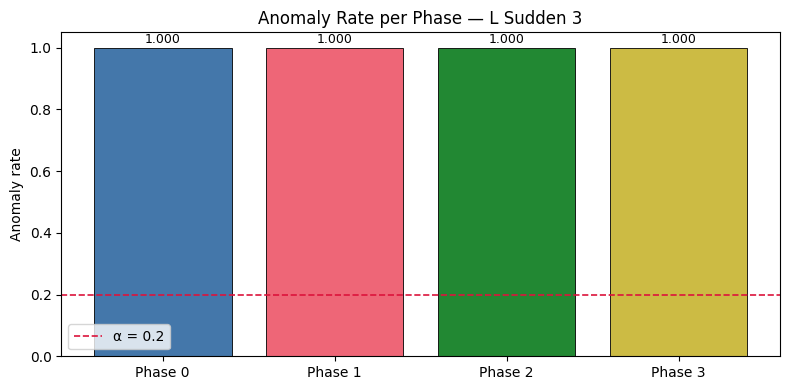

In [9]:
import pandas as pd

rows = []
for p in range(N_PHASES):
    start = p * N_PER_PHASE
    end   = start + N_PER_PHASE
    pv    = p_values[start:end]
    an    = anomalies[start:end]
    rows.append({
        'Phase': p,
        'Description': phase_names[p],
        'Mean p-value': f'{pv.mean():.4f}',
        'Median p-value': f'{np.median(pv):.4f}',
        'Anomaly rate': f'{an.mean():.4f}',
    })

df = pd.DataFrame(rows).set_index('Phase')
print(df.to_string())

# Bar chart of anomaly rates per phase
fig, ax = plt.subplots(figsize=(8, 4))
rates = [float(r['Anomaly rate']) for r in rows]
bars  = ax.bar(range(N_PHASES), rates, color=phase_colors, edgecolor='black', linewidth=0.6)
ax.axhline(ALPHA, color='crimson', linestyle='--', linewidth=1.2, label=f'α = {ALPHA}')
ax.set_xticks(range(N_PHASES))
ax.set_xticklabels([f'Phase {p}' for p in range(N_PHASES)])
ax.set_ylabel('Anomaly rate')
ax.set_title('Anomaly Rate per Phase — L Sudden 3')
ax.legend()
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{rate:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
